# HR Text Analysis — NLP & Sentiment Analysis Pipeline

**Dataset**: `HRDataset_v14_enriched.csv`  
**Objective**: Identify attrition drivers by analyzing HR text (exit interview feedback, transfer requests) and predict which employees are at risk of leaving the company.

## Dependency Installation
```bash
pip install pandas scikit-learn matplotlib seaborn
```

In [1]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.family": "DejaVu Sans"})

COLORS = {
    "positive": "#2ecc71",
    "negative": "#e74c3c",
    "neutral":  "#95a5a6",
    "primary":  "#2c3e50",
    "accent":   "#3498db",
}

print("Libraries loaded successfully")

Libraries loaded successfully


---
## BLOCK 1 — Loading & Exploring Text Data

### Context

The dataset contains **311 employees** and two simulated text columns:

- **`ExitInterview_Feedback`**: for employees who left, an exit interview excerpt aligned with the departure reason (`TermReason`); for active employees, a satisfaction survey comment aligned with `EmpSatisfaction` and `EngagementSurvey` scores.
- **`InternalTransferRequest`**: formal internal mobility request (present for ~40% of active employees and ~30% of voluntary leavers).

> **Why simulated text?** In an educational context, real HR interviews are confidential. The generated text here reproduces realistic linguistic patterns you would find in real datasets.

In [2]:
# Load enriched dataset
df = pd.read_csv("HRDataset_v14_enriched.csv", encoding="utf-8-sig")

# Text columns and target
TEXT_FEEDBACK = "ExitInterview_Feedback"
TEXT_TRANSFER = "InternalTransferRequest"
TARGET_COL    = "EmploymentStatus"

# Binary target: 1 = left, 0 = still active
df["Attrition"] = df[TARGET_COL].apply(
    lambda x: 1 if x in ("Voluntarily Terminated", "Terminated for Cause") else 0
)

# Clean NaN values
df[TEXT_FEEDBACK] = df[TEXT_FEEDBACK].fillna("")
df[TEXT_TRANSFER] = df[TEXT_TRANSFER].fillna("")

print(f"Dataset shape: {df.shape}")
df[["Employee_Name", "EmploymentStatus", "TermReason", "EmpSatisfaction", "ExitInterview_Feedback"]].head(4)

Dataset shape: (311, 39)


,Employee_Name,EmploymentStatus,TermReason,EmpSatisfaction,ExitInterview_Feedback
0,"Adinolfi, Wilson K",Active,N/A-StillEmployed,5,Adinolfi shared positive feedback about the te...
1,"Ait Sidi, Karthikeyan",Voluntarily Terminated,career change,3,"During the interview, Ait Sidi explained that ..."
2,"Akinkuolie, Sarah",Voluntarily Terminated,hours,3,Akinkuolie noted that sustained periods of ove...
3,"Alagbe,Trina",Active,N/A-StillEmployed,5,Alagbe shared positive feedback about the team...


In [3]:
# Descriptive statistics on text columns
stats = pd.DataFrame({
    "Column": [TEXT_FEEDBACK, TEXT_TRANSFER],
    "Filled (n)": [
        (df[TEXT_FEEDBACK] != "").sum(),
        (df[TEXT_TRANSFER] != "").sum(),
    ],
    "Average length (chars)": [
        df[df[TEXT_FEEDBACK] != ""][TEXT_FEEDBACK].str.len().mean().round(0),
        df[df[TEXT_TRANSFER] != ""][TEXT_TRANSFER].str.len().mean().round(0),
    ],
    "Max length (chars)": [
        df[TEXT_FEEDBACK].str.len().max(),
        df[TEXT_TRANSFER].str.len().max(),
    ],
})
print(stats.to_string(index=False))

                 Column  Filled (n)  Average length (chars)  Max length (chars)
 ExitInterview_Feedback         311                   276.0                 345
InternalTransferRequest          46                   438.0                 501


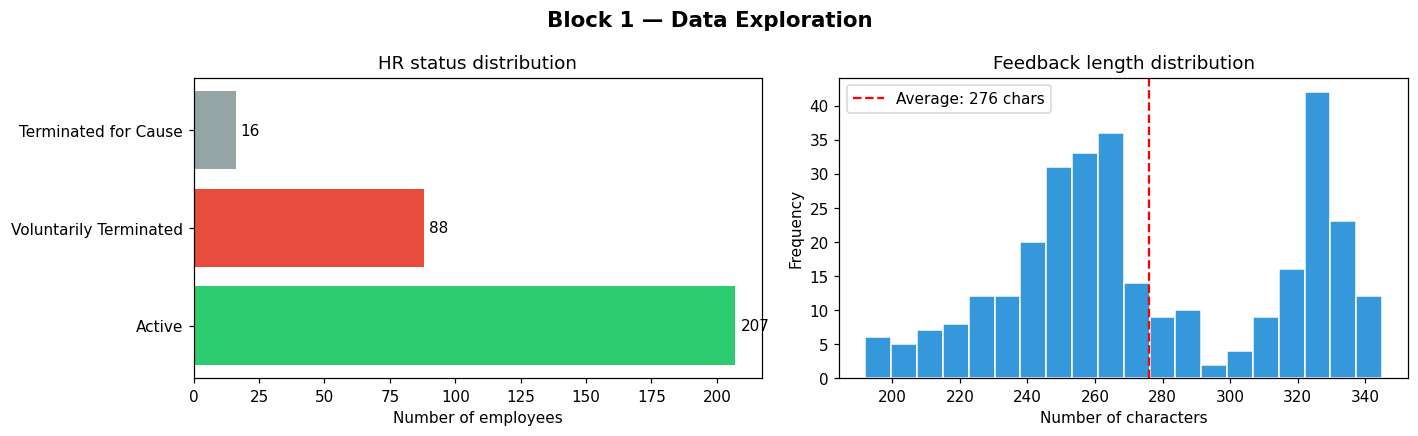

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Block 1 — Data Exploration", fontsize=14, fontweight="bold")

# Status distribution
counts = df[TARGET_COL].value_counts()
axes[0].barh(counts.index, counts.values,
             color=[COLORS["positive"], COLORS["negative"], COLORS["neutral"]])
axes[0].set_title("HR status distribution")
axes[0].set_xlabel("Number of employees")
for i, v in enumerate(counts.values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=10)

# Feedback length distribution
lengths = df[df[TEXT_FEEDBACK] != ""][TEXT_FEEDBACK].str.len()
axes[1].hist(lengths, bins=20, color=COLORS["accent"], edgecolor="white")
axes[1].axvline(lengths.mean(), color="red", linestyle="--", label=f"Average: {lengths.mean():.0f} chars")
axes[1].set_title("Feedback length distribution")
axes[1].set_xlabel("Number of characters")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## BLOCK 2 — Approach 1: Lexicon-Based Sentiment Analysis (Rules)

### Principle

The simplest approach: build two lexicons of positive and negative words, then compute for each text:

$$\text{score} = \frac{\#\text{positive words} - \#\text{negative words}}{\#\text{total words}}$$

| Score | Label |
|-------|-------|
| > +0.02 | **positive** |
| < -0.02 | **negative** |
| between the two | **neutral** |

We also handle simple negation: if a positive word is preceded by *"not"*, *"no"*, *"never"*... it is counted as negative.

**Advantages**: transparent, fast, no training required, word-level explainable  
**Limitations**: limited context understanding, sensitive to irony, depends on lexicon quality

> **Responsible AI**: This method is fully interpretable — we can show exactly which words contributed to each employee's score.

In [5]:
# ── Lexicons ─────────────────────────────────────────────────────────────────
POSITIVE_WORDS = {
    "positive", "appreciated", "valued", "satisfied", "happy", "proud",
    "collaborative", "supportive", "excellent", "strong", "growth",
    "recognition", "flexibility", "transparent", "engaged", "rewarding",
    "commended", "praised", "achievement", "alignment", "trust",
    "motivated", "welcoming", "enthusiastic", "warmly", "succeed",
    "opportunity", "benefited", "smooth", "genuine", "constructive",
    "effective", "open", "balance", "healthy",
}

NEGATIVE_WORDS = {
    "dissatisfied", "unhappy", "frustrated", "micromanaged", "overworked",
    "stagnant", "ignored", "unclear", "punitive", "conflict", "tense",
    "exhausted", "unresolved", "fear", "reprisal", "low", "broken",
    "negative", "concern", "complaint", "disappointment", "inadequate",
    "poorly", "misaligned", "leaving", "resigned", "resignation",
    "terminated", "departure", "lack", "unable", "untenable",
    "demotivating", "deterioration", "incompatible", "reluctantly",
    "disconnect", "opaque", "chronic",
}

NEGATION_WORDS = {"not", "no", "never", "without", "lack", "barely", "hardly"}

print(f"Positive lexicon: {len(POSITIVE_WORDS)} words")
print(f"Negative lexicon: {len(NEGATIVE_WORDS)} words")

Positive lexicon: 35 words
Negative lexicon: 39 words


In [6]:
def tokenize(text: str) -> list:
    """Basic cleaning: lowercase and punctuation removal."""
    return re.findall(r"\b[a-z]+\b", text.lower())


def lexical_sentiment(text: str, threshold: float = 0.02) -> dict:
    """
    Computes a text sentiment score.
    Handles simple negation (window of 2 words before the evaluated word).

    Returns: score, label, detected positive words and negative words.
    """
    if not text.strip():
        return {"score": 0.0, "label": "neutral", "pos_words": [], "neg_words": []}

    tokens = tokenize(text)
    n = len(tokens)
    if n == 0:
        return {"score": 0.0, "label": "neutral", "pos_words": [], "neg_words": []}

    pos_score, neg_score = 0, 0
    found_pos, found_neg = [], []

    for i, token in enumerate(tokens):
        # Negation window: the 2 previous tokens
        context = tokens[max(0, i - 2): i]
        negated = any(w in NEGATION_WORDS for w in context)

        if token in POSITIVE_WORDS:
            if negated:
                neg_score += 1
                found_neg.append(f"not_{token}")
            else:
                pos_score += 1
                found_pos.append(token)
        elif token in NEGATIVE_WORDS:
            if negated:
                pos_score += 1
                found_pos.append(f"not_{token}")
            else:
                neg_score += 1
                found_neg.append(token)

    score = (pos_score - neg_score) / n
    label = "positive" if score > threshold else ("negative" if score < -threshold else "neutral")

    return {"score": round(score, 4), "label": label,
            "pos_words": found_pos, "neg_words": found_neg}


# ── Apply to the full dataset ────────────────────────────────────────────────
results = df[TEXT_FEEDBACK].apply(lexical_sentiment)
df["sentiment_score"] = results.apply(lambda x: x["score"])
df["sentiment_label"] = results.apply(lambda x: x["label"])

# Summary
dist = df["sentiment_label"].value_counts()
print("Sentiment distribution:")
for label, count in dist.items():
    bar = "█" * int(count / 3)
    print(f"  {label:<12} : {count:>4} ({count/len(df)*100:.1f}%)  {bar}")

Sentiment distribution:
  positive     :  144 (46.3%)  ████████████████████████████████████████████████
  neutral      :  129 (41.5%)  ███████████████████████████████████████████
  negative     :   38 (12.2%)  ████████████


In [7]:
# ── Example of individual explanation ───────────────────────────────────────
print("Example of individual interpretation\n")

# Select a negative employee sample
neg_idx = df[df["sentiment_label"] == "negative"].index[0]
ex = results.iloc[neg_idx]

print(f"Employee   : {df['Employee_Name'].iloc[neg_idx]}")
print(f"Status     : {df[TARGET_COL].iloc[neg_idx]}")
print(f"Feedback   : {df[TEXT_FEEDBACK].iloc[neg_idx][:200]}...")
print(f"\nScore      : {ex['score']}")
print(f"Label      : {ex['label']}")
print(f"Words (+)  : {ex['pos_words']}")
print(f"Words (-)  : {ex['neg_words']}")

Example of individual interpretation

Employee   : Ait Sidi, Karthikeyan   
Status     : Voluntarily Terminated
Feedback   : During the interview, Ait Sidi explained that after several years in the IT/IS department, they felt ready for a fundamentally different challenge. They spoke positively about their colleagues but ind...

Score      : -0.0244
Label      : negative
Words (+)  : []
Words (-)  : ['misaligned']


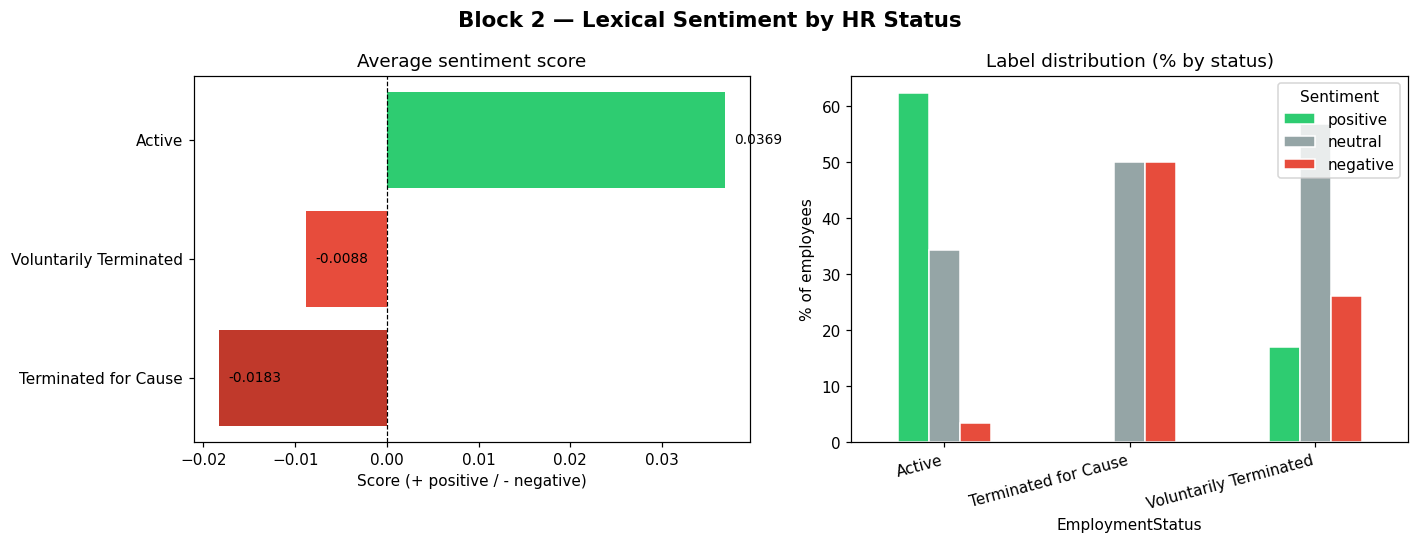

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Block 2 — Lexical Sentiment by HR Status", fontsize=14, fontweight="bold")

# Average score by status
means = df.groupby(TARGET_COL)["sentiment_score"].mean().sort_values()
palette = {
    "Active": COLORS["positive"],
    "Voluntarily Terminated": COLORS["negative"],
    "Terminated for Cause": "#c0392b",
}
colors = [palette.get(s, COLORS["neutral"]) for s in means.index]
bars = axes[0].barh(means.index, means.values, color=colors)
axes[0].set_title("Average sentiment score")
axes[0].set_xlabel("Score (+ positive / - negative)")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, means.values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

# Label distribution by status
ct = pd.crosstab(df[TARGET_COL], df["sentiment_label"], normalize="index") * 100
for col in ["positive", "neutral", "negative"]:
    if col not in ct.columns:
        ct[col] = 0
ct = ct[["positive", "neutral", "negative"]]
ct.plot(kind="bar", ax=axes[1],
        color=[COLORS["positive"], COLORS["neutral"], COLORS["negative"]],
        edgecolor="white")
axes[1].set_title("Label distribution (% by status)")
axes[1].set_ylabel("% of employees")
axes[1].set_xticklabels(ct.index, rotation=15, ha="right")
axes[1].legend(title="Sentiment")

plt.tight_layout()
plt.show()

---
## BLOCK 3 — Approach 2: ML Classification (TF-IDF + Logistic Regression)

### Principle

#### TF-IDF (Term Frequency – Inverse Document Frequency)
Each text is transformed into a numeric vector: each dimension corresponds to a vocabulary word, and its value reflects the word's relative importance in the document.

$$\text{TF-IDF}(t, d) = \underbrace{\frac{f_{t,d}}{|d|}}_{\text{local frequency}} \times \underbrace{\log\frac{N}{n_t}}_{\text{global rarity}}$$

→ *"resignation"* carries more weight than *"the"* because it is rarer across all documents.

#### Logistic Regression
Supervised linear model: it learns from labeled texts (active / left) which words are the best predictors. Coefficients represent each word's influence.

**Advantages**: interpretable, fast, strong baseline  
**Limitations**: ignores word order, limited deep semantics

> **Responsible AI**: We use 5-fold cross-validation to reduce overfitting risk. We also check that the model is not relying on demographic proxies.

In [9]:
# Data preparation
mask = df[TEXT_FEEDBACK].str.len() > 20
X_text = df.loc[mask, TEXT_FEEDBACK]
y      = df.loc[mask, "Attrition"]

print(f"Sample size: {len(X_text)} texts")
print(f"  Class 0 (active): {(y == 0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Class 1 (left):   {(y == 1).sum()} ({(y==1).mean()*100:.1f}%)")

# TF-IDF -> Logistic Regression pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=500,         # top 500 most informative terms
        ngram_range=(1, 2),       # unigrams + bigrams
        stop_words="english",
        min_df=2,                 # token appears in >= 2 documents
        sublinear_tf=True,        # log-scaling of term frequencies
    )),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced", # compensate class imbalance
        max_iter=1000,
        random_state=42,
    )),
])

# Cross-validation (5 folds)
cv_scores = cross_val_score(pipeline, X_text, y, cv=5, scoring="f1", n_jobs=-1)
print(f"\nCross-validation F1 (5 folds):")
print(f"  Scores : {[round(s, 3) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

Sample size: 311 texts
  Class 0 (active): 207 (66.6%)
  Class 1 (left):   104 (33.4%)

Cross-validation F1 (5 folds):
  Scores : [np.float64(0.955), np.float64(0.93), np.float64(1.0), np.float64(1.0), np.float64(0.977)]
  Mean   : 0.972 +/- 0.027


In [10]:
# Final training + evaluation on test set
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Classification report (test set - {len(y_test)} examples):\n")
print(classification_report(y_test, y_pred, target_names=["Active", "Left"]))

Classification report (test set - 63 examples):

              precision    recall  f1-score   support

      Active       1.00      0.95      0.98        42
        Left       0.91      1.00      0.95        21

    accuracy                           0.97        63
   macro avg       0.96      0.98      0.97        63
weighted avg       0.97      0.97      0.97        63



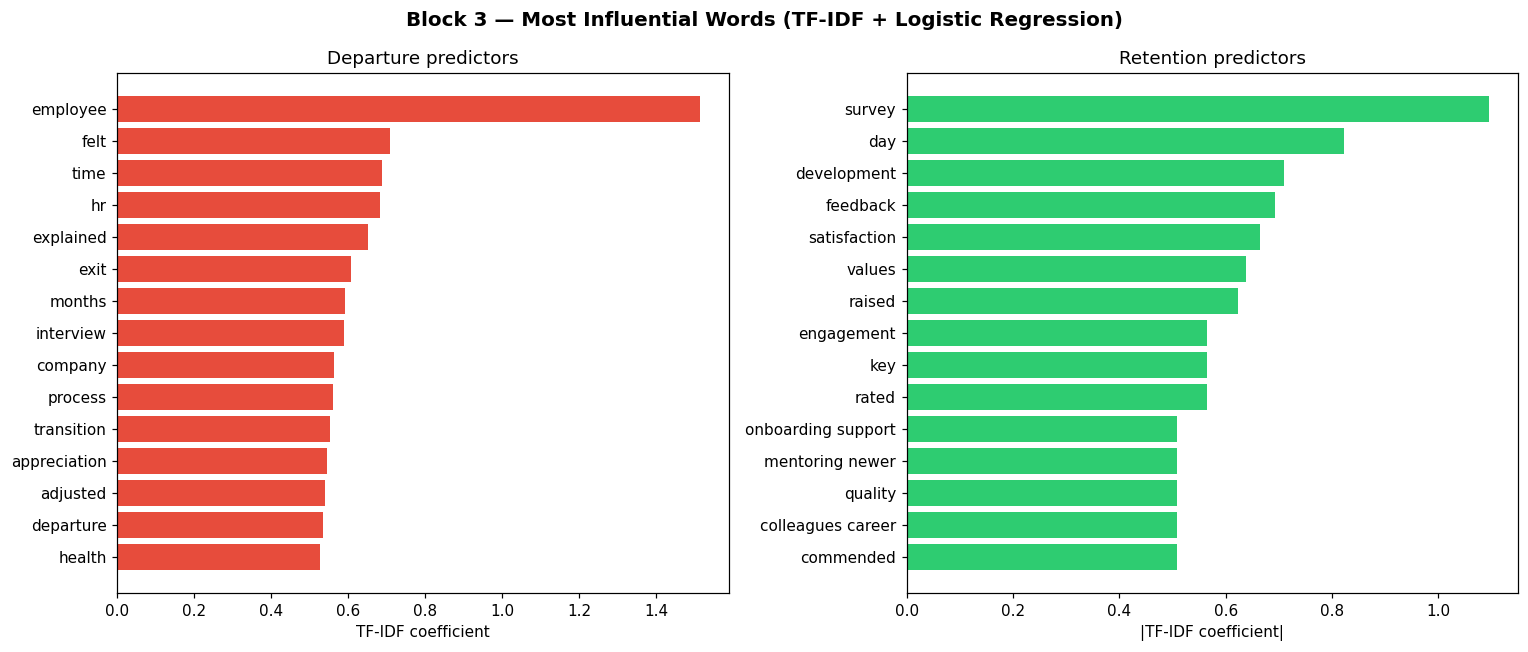

In [11]:
# Most influential words by class
vocab = pipeline.named_steps["tfidf"].get_feature_names_out()
coef  = pipeline.named_steps["clf"].coef_[0]
top_n = 15

idx_depart  = np.argsort(coef)[-top_n:][::-1]
idx_maintain = np.argsort(coef)[:top_n]

words_depart  = [(vocab[i], coef[i]) for i in idx_depart]
words_maintain = [(vocab[i], abs(coef[i])) for i in idx_maintain]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Block 3 — Most Influential Words (TF-IDF + Logistic Regression)",
             fontsize=13, fontweight="bold")

w_dep = [w for w, _ in words_depart]
c_dep = [c for _, c in words_depart]
axes[0].barh(w_dep[::-1], c_dep[::-1], color=COLORS["negative"])
axes[0].set_title("Departure predictors")
axes[0].set_xlabel("TF-IDF coefficient")

w_mai = [w for w, _ in words_maintain]
c_mai = [c for _, c in words_maintain]
axes[1].barh(w_mai[::-1], c_mai[::-1], color=COLORS["positive"])
axes[1].set_title("Retention predictors")
axes[1].set_xlabel("|TF-IDF coefficient|")

plt.tight_layout()
plt.show()

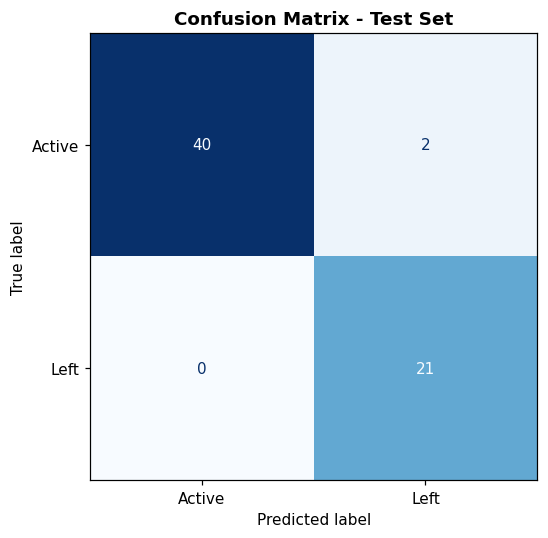


Matrix reading:
  Row = actual | Column = model prediction
  False negatives (left predicted active): 0 - risk of missing an HR alert
  False positives (active predicted left): 2 - risk of unnecessary HR escalation


In [12]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Active", "Left"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix - Test Set", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nMatrix reading:")
print("  Row = actual | Column = model prediction")
print(f"  False negatives (left predicted active): {cm[1][0]} - risk of missing an HR alert")
print(f"  False positives (active predicted left): {cm[0][1]} - risk of unnecessary HR escalation")

---
## BLOCK 4 — Approach 3: Theme Extraction (TF-IDF + K-Means)

### Principle

Unlike Block 3 (supervised), we do not use predefined labels here. The algorithm discovers groups of similar texts on its own.

**Steps:**
1. TF-IDF -> high-dimensional vectors (500 dimensions)
2. **LSA** (Latent Semantic Analysis = TruncatedSVD) -> reduce to 50 dimensions while preserving semantic structure
3. **K-Means** -> cluster texts into K groups by cosine similarity
4. **2D SVD projection** -> visualization

> **Responsible AI**: Clusters represent groups of texts, not groups of people. Each theme must be interpreted by HR experts — the algorithm suggests, humans decide.

In [13]:
K = 5  # Number of themes

# Vectorization + LSA reduction
tfidf_topics = TfidfVectorizer(
    max_features=300, ngram_range=(1, 2),
    stop_words="english", min_df=2, sublinear_tf=True
)
mask2 = df[TEXT_FEEDBACK].str.len() > 20
X_all = df.loc[mask2, TEXT_FEEDBACK]
X_tfidf = tfidf_topics.fit_transform(X_all)

svd = TruncatedSVD(n_components=50, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)

# K-Means clustering
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_lsa)

df_topics = df.loc[mask2].copy()
df_topics["topic"] = clusters
df["topic"] = np.nan
df.loc[mask2, "topic"] = clusters

# Top words per theme
vocab_t = tfidf_topics.get_feature_names_out()
centroids = kmeans.cluster_centers_ @ svd.components_

print(f"{K} themes identified in feedback texts:\n")
for k in range(K):
    top_idx   = np.argsort(centroids[k])[-8:][::-1]
    top_words = [vocab_t[i] for i in top_idx]
    n_in_cluster = (clusters == k).sum()
    print(f"  Theme {k} ({n_in_cluster} texts): {', '.join(top_words)}")

5 themes identified in feedback texts:

  Theme 0 (35 texts): day, coming review, committed, committed role, coming, team equitable, cycle, day day
  Theme 1 (35 texts): commended quality, support received, commended, colleagues career, feedback team, positive feedback, onboarding support, onboarding
  Theme 2 (36 texts): clearly, clearly communicated, survey indicated, communicated welcome, feels reasonably, reasonably settled, feedback development, feels
  Theme 3 (38 texts): career progression, acknowledged positive, suggested, suggested regular, concerns limited, sessions, sessions management, survey response
  Theme 4 (167 texts): employee, company, expressed, felt, team, production, described, personal


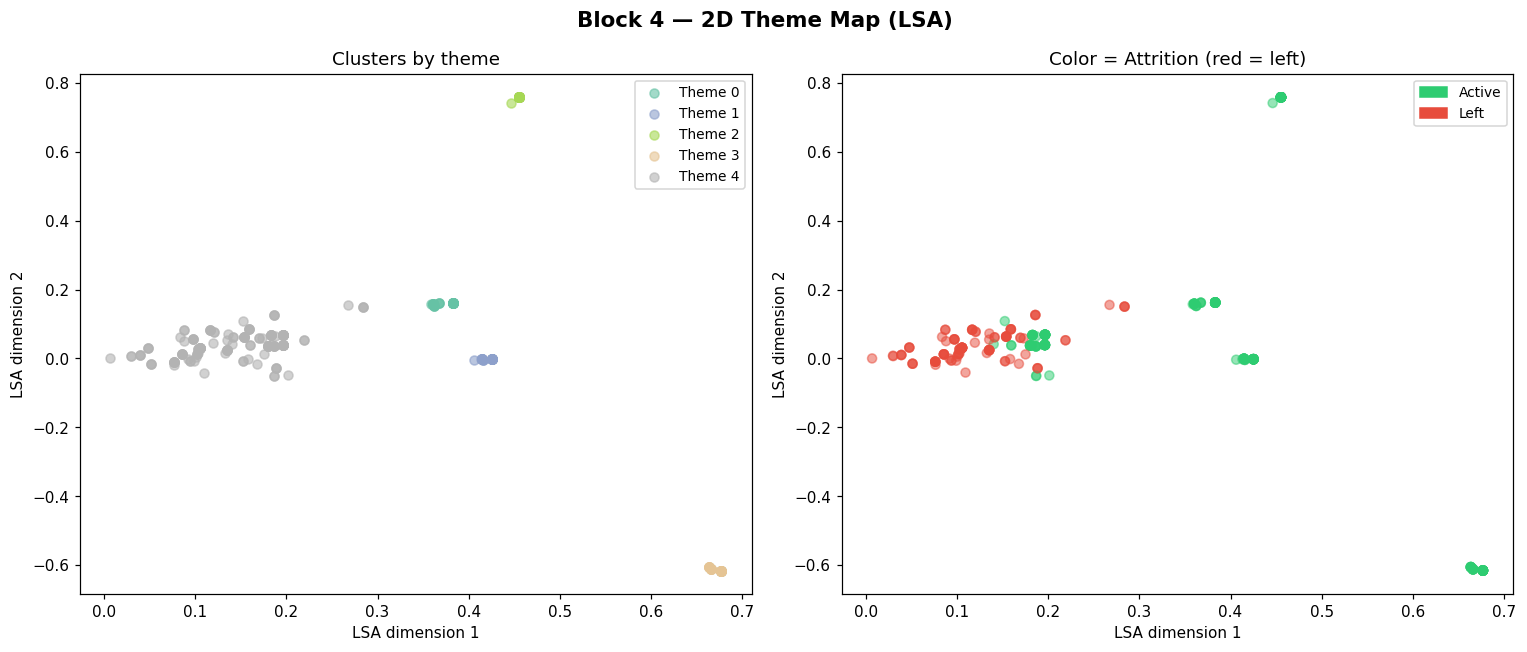

In [14]:
# 2D projection for visualization
svd2d = TruncatedSVD(n_components=2, random_state=42)
X_2d  = svd2d.fit_transform(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Block 4 — 2D Theme Map (LSA)", fontsize=14, fontweight="bold")

# By theme
palette = plt.cm.Set2(np.linspace(0, 1, K))
for k in range(K):
    m = clusters == k
    axes[0].scatter(X_2d[m, 0], X_2d[m, 1], c=[palette[k]], label=f"Theme {k}", alpha=0.6, s=35)
axes[0].set_title("Clusters by theme")
axes[0].legend(fontsize=9)
axes[0].set_xlabel("LSA dimension 1")
axes[0].set_ylabel("LSA dimension 2")

# By attrition
att_vals = df_topics["Attrition"].values
c_att = [COLORS["negative"] if a else COLORS["positive"] for a in att_vals]
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=c_att, alpha=0.5, s=35)
axes[1].set_title("Color = Attrition (red = left)")
axes[1].set_xlabel("LSA dimension 1")
axes[1].set_ylabel("LSA dimension 2")
axes[1].legend(handles=[
    mpatches.Patch(color=COLORS["positive"], label="Active"),
    mpatches.Patch(color=COLORS["negative"], label="Left"),
], fontsize=9)

plt.tight_layout()
plt.show()

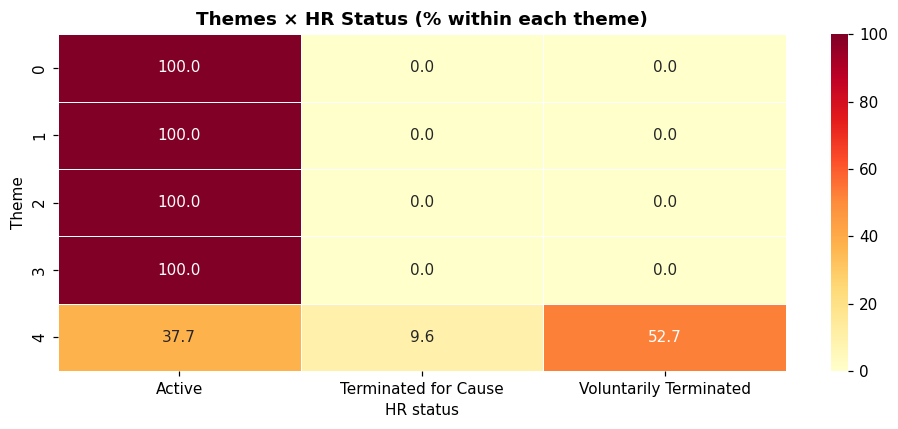


Interpretation: a theme with a high 'Voluntarily Terminated' share
corresponds to a linguistic profile associated with voluntary departures.


In [15]:
# Heatmap: themes × status
ct_topics = pd.crosstab(
    df_topics["topic"], df_topics[TARGET_COL], normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(ct_topics, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("Themes × HR Status (% within each theme)", fontweight="bold")
ax.set_xlabel("HR status")
ax.set_ylabel("Theme")
plt.tight_layout()
plt.show()

print("\nInterpretation: a theme with a high 'Voluntarily Terminated' share")
print("corresponds to a linguistic profile associated with voluntary departures.")

---
## BLOCK 5 — NLP × Structured Data Integration & Risk Scoring

### Principle

We combine NLP outputs with structured numeric variables to build a 360-degree view of each employee.

**Combined risk score:**

$$\text{risk\_score} = -\text{sentiment\_score} \times 10 + (5 - \text{EmpSatisfaction}) + (5 - \text{EngagementSurvey}) + \text{Absences} \times 0.1$$

> **Responsible AI**: This score is an alert signal, not a verdict. It should trigger an HR conversation, never an automated decision (blocked promotion, preventive dismissal, etc.).

In [16]:
# Correlations between NLP score and numeric variables
corr_cols = ["sentiment_score", "EmpSatisfaction", "EngagementSurvey",
             "Attrition", "Salary", "Absences", "DaysLateLast30"]
corr_data = df[corr_cols].dropna()

print("Correlations with NLP sentiment score:\n")
corr = corr_data.corr()["sentiment_score"].drop("sentiment_score").sort_values()
for var, val in corr.items():
    bar = "█" * int(abs(val) * 20)
    sign = "+" if val > 0 else "-"
    print(f"  {var:<25} : {val:+.3f}  {sign}{bar}")

Correlations with NLP sentiment score:

  Attrition                 : -0.492  -█████████
  DaysLateLast30            : -0.209  -████
  Absences                  : -0.026  -
  Salary                    : +0.017  +
  EngagementSurvey          : +0.298  +█████
  EmpSatisfaction           : +0.419  +████████


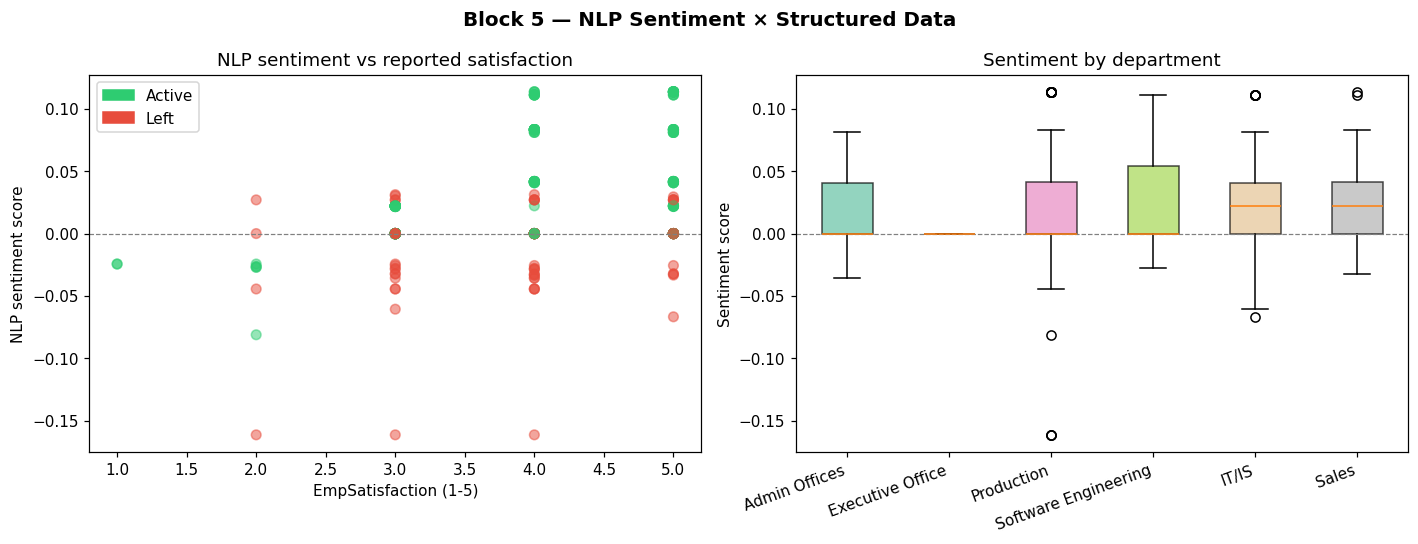

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Block 5 — NLP Sentiment × Structured Data", fontsize=13, fontweight="bold")

# Scatter: sentiment vs satisfaction
colors_s = [COLORS["negative"] if a else COLORS["positive"] for a in corr_data["Attrition"]]
axes[0].scatter(corr_data["EmpSatisfaction"], corr_data["sentiment_score"],
                c=colors_s, alpha=0.5, s=40)
axes[0].set_xlabel("EmpSatisfaction (1-5)")
axes[0].set_ylabel("NLP sentiment score")
axes[0].set_title("NLP sentiment vs reported satisfaction")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].legend(handles=[
    mpatches.Patch(color=COLORS["positive"], label="Active"),
    mpatches.Patch(color=COLORS["negative"], label="Left"),
])

# Boxplot by department
dept_order = df.groupby("Department")["sentiment_score"].median().sort_values().index
dept_data  = [df[df["Department"] == d]["sentiment_score"].dropna().values for d in dept_order]
bp = axes[1].boxplot(dept_data, patch_artist=True,
                     labels=[d.strip() for d in dept_order])
for patch, color in zip(bp["boxes"], plt.cm.Set2(np.linspace(0, 1, len(dept_order)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Sentiment by department")
axes[1].set_ylabel("Sentiment score")
axes[1].set_xticklabels([d.strip() for d in dept_order], rotation=20, ha="right")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [18]:
# Compute combined risk score
df["risk_score"] = (
    - df["sentiment_score"] * 10
    + (5 - df["EmpSatisfaction"])
    + (5 - df["EngagementSurvey"])
    + df["Absences"].fillna(0) * 0.1
).round(2)

# Top 10 active employees at highest risk
at_risk = (
    df[df[TARGET_COL] == "Active"]
    .sort_values("risk_score", ascending=False)
    [["Employee_Name", "Department", "sentiment_label",
      "EmpSatisfaction", "EngagementSurvey", "risk_score"]]
    .head(10)
)

print("Top 10 active employees with the highest risk score:\n")
print(at_risk.to_string(index=False))
print("\nThis score is an ALERT SIGNAL — trigger an HR conversation, not an automatic action.")

Top 10 active employees with the highest risk score:

     Employee_Name           Department sentiment_label  EmpSatisfaction  EngagementSurvey  risk_score
 Dietrich, Jenna                  Sales        negative                1              2.30        8.64
   Desimone, Carl     Production               negative                2              1.12        8.05
  Sparks, Taylor      Production               negative                2              2.40        7.87
Stansfield, Norman                Sales        negative                2              1.81        6.93
    Erilus, Angela    Production               negative                1              3.00        6.74
        Fett, Boba                IT/IS         neutral                3              1.20        6.00
     Monroe, Peter                IT/IS         neutral                3              2.39        5.91
   Valentin,Jackie                Sales         neutral                3              2.81        5.79
   Andreola, Colby 

---
## Final Summary

In [19]:
# Summary table of generated columns
print("Columns added to the dataset:\n")
new_cols = [
    ("sentiment_score",  "Numeric score [-1, +1]",                         "Block 2"),
    ("sentiment_label",  "positive / neutral / negative",                   "Block 2"),
    ("topic",            "Theme number (0 to 4)",                           "Block 4"),
    ("risk_score",       "Combined risk score (HR alert signal)",           "Block 5"),
]
for col, desc, bloc in new_cols:
    print(f"  {col:<20} ({bloc}) - {desc}")

print("\nKey results:\n")
print(f"  - Average sentiment (active) : {df[df['Attrition']==0]['sentiment_score'].mean():+.4f}")
print(f"  - Average sentiment (left)   : {df[df['Attrition']==1]['sentiment_score'].mean():+.4f}")
print(f"  - ML model F1-score          : {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"  - Sentiment/satisfaction corr: {df[['sentiment_score','EmpSatisfaction']].corr().iloc[0,1]:+.3f}")
print(f"\n  Top 3 at-risk active employees:")
for _, row in at_risk.head(3).iterrows():
    print(f"    -> {row['Employee_Name']} ({row['Department'].strip()}) - score: {row['risk_score']}")

Columns added to the dataset:

  sentiment_score      (Block 2) - Numeric score [-1, +1]
  sentiment_label      (Block 2) - positive / neutral / negative
  topic                (Block 4) - Theme number (0 to 4)
  risk_score           (Block 5) - Combined risk score (HR alert signal)

Key results:

  - Average sentiment (active) : +0.0369
  - Average sentiment (left)   : -0.0103
  - ML model F1-score          : 0.972 +/- 0.027
  - Sentiment/satisfaction corr: +0.419

  Top 3 at-risk active employees:
    -> Dietrich, Jenna   (Sales) - score: 8.64
    -> Desimone, Carl  (Production) - score: 8.05
    -> Sparks, Taylor   (Production) - score: 7.87


In [20]:
# Export final dataset enriched with NLP columns
output_cols = list(df.columns)
df.to_csv("HRDataset_v14_nlp_final.csv", index=False, encoding="utf-8-sig")
print(f"Exported dataset: HRDataset_v14_nlp_final.csv ({df.shape[0]} rows x {df.shape[1]} columns)")
print("New NLP columns: sentiment_score, sentiment_label, topic, risk_score")

Exported dataset: HRDataset_v14_nlp_final.csv (311 rows x 43 columns)
New NLP columns: sentiment_score, sentiment_label, topic, risk_score
